# Residual study

`scp fermi:~/kerr/toby_files/toby_v3.* .`

In [1]:
%reset -f
%run pylib/tools dark date
from pylib import kerr_funcs; reload(kerr_funcs)
from pylib.kerr_funcs import *
pixel_table = PixelTable('files/kerr/toby_v3')

<h5 style="text-align:right; margin-right:15px"> 2026-03-21 10:29</h5>

Loaded Kerr model from "files/kerr/toby_v3.npz":
            43 bands Band(0, 4): psf0@1.33 GeV nside 64 occ 1.000 ... Band(3, 11): psf3@74.99 GeV nside 2048 occ 0.000
            206,555,017 photons
            8,241,643 pixels
            


## plot residuals for 1.33 GeV 

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x765f732d2fb0>
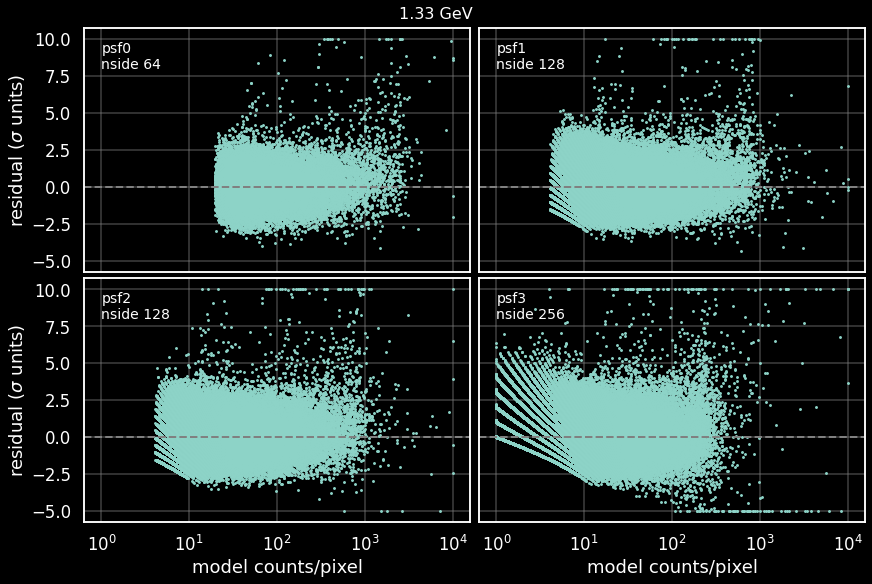

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x765f73228760>
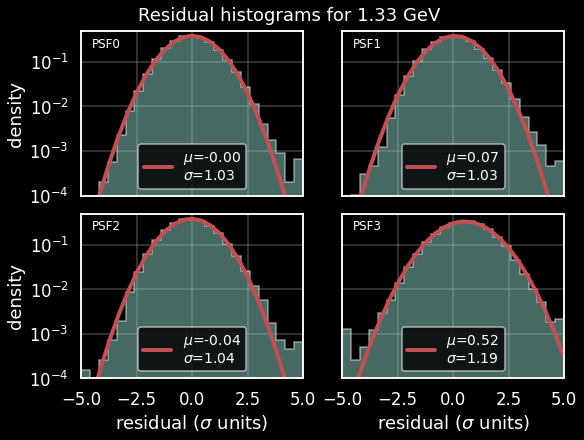

In [2]:
show(f'## plot residuals for {pixel_table(0,(energy_index:=4)).energy} ')
show_fig(plot_residuals_for_given_energy,pixel_table, energy_index)   
show_fig(histograms_of_residuals_for_given_energy,pixel_table, energy_index)

In [3]:
reload(kerr_funcs); from pylib.kerr_funcs import ResidualPoints
self = ResidualPoints(pixel_table, energy_index=energy_index)

self.df.describe()

,pixel,data,model,sigma,glon,glat,psf,nside
count,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000
mean,319467.148936,1510.228723,1304.955479,6.929746,-8.727927,3.440485,2.648936,228.425532
std,228324.213763,4668.816442,4239.229653,4.040029,108.334218,42.002258,0.823550,59.218347
min,3967.000000,6.000000,0.914720,5.001661,-175.429688,-86.161712,0.000000,64.000000
25%,94605.750000,10.000000,1.927054,5.223226,-101.023996,-30.518231,3.000000,256.000000
50%,301118.500000,57.000000,26.082821,5.656355,-3.691406,1.044512,3.000000,256.000000
75%,496775.750000,584.250000,464.891962,6.973574,87.916067,32.708594,3.000000,256.000000
max,764128.000000,39815.000000,38598.181295,38.612966,179.648438,83.417689,3.000000,256.000000


In [4]:
self.clusterer()
self.cldf

,glon,glat,data,model,sigma,n,ids
0,85.000,83.418,218,147.3,5.8,8,"[0, 38, 37, 36, 35, 21, 20, 11]"
1,-38.672,17.270,1323,989.8,10.6,9,"[1, 89, 88, 87, 27, 26, 25, 14, 13]"
2,-164.883,4.182,17908,16391.7,11.8,12,"[2, 101, 5, 4, 100, 99, 98, 97, 96, 28, 15, 3]"
3,-96.328,-2.687,39815,38598.2,6.2,8,"[6, 129, 8, 127, 125, 123, 29, 7]"
4,127.969,-30.692,165,108.1,5.5,7,"[9, 150, 149, 148, 147, 32, 31]"
5,-71.250,-63.448,93,52.2,5.6,3,"[10, 178, 34]"
6,99.844,-31.039,74,35.5,6.5,4,"[17, 153, 152, 18]"
7,-160.714,78.468,240,162.9,6.0,2,"[41, 43]"
8,49.821,64.199,9,1.9,5.2,2,"[48, 49]"
9,63.457,41.014,100,59.3,5.3,2,"[69, 70]"


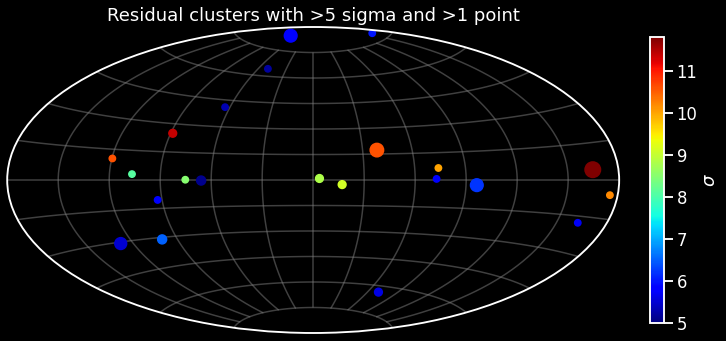

In [5]:
self.ait_cluster_plot()

In [6]:
from utilities.catalogs import UWcat, Fermi4FGL
show(f""" ## Compare with {(fglname:='uw1617')}""")
fgl = Fermi4FGL(fglname)
# for test in ResidualPoints(pixel_table(1,4)).points:
#     t  = fgl.catalog_entry(test, 1)
#     if t is not None:
#         print(t.name, round(t.ts),  round(t.sep,1))

## Compare with uw1617

Loaded Fermi 4FGL gll_pscP305uw1617_v4_assoc_v9r1_classes.fits: 7221 entries


<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x765f71b45060>
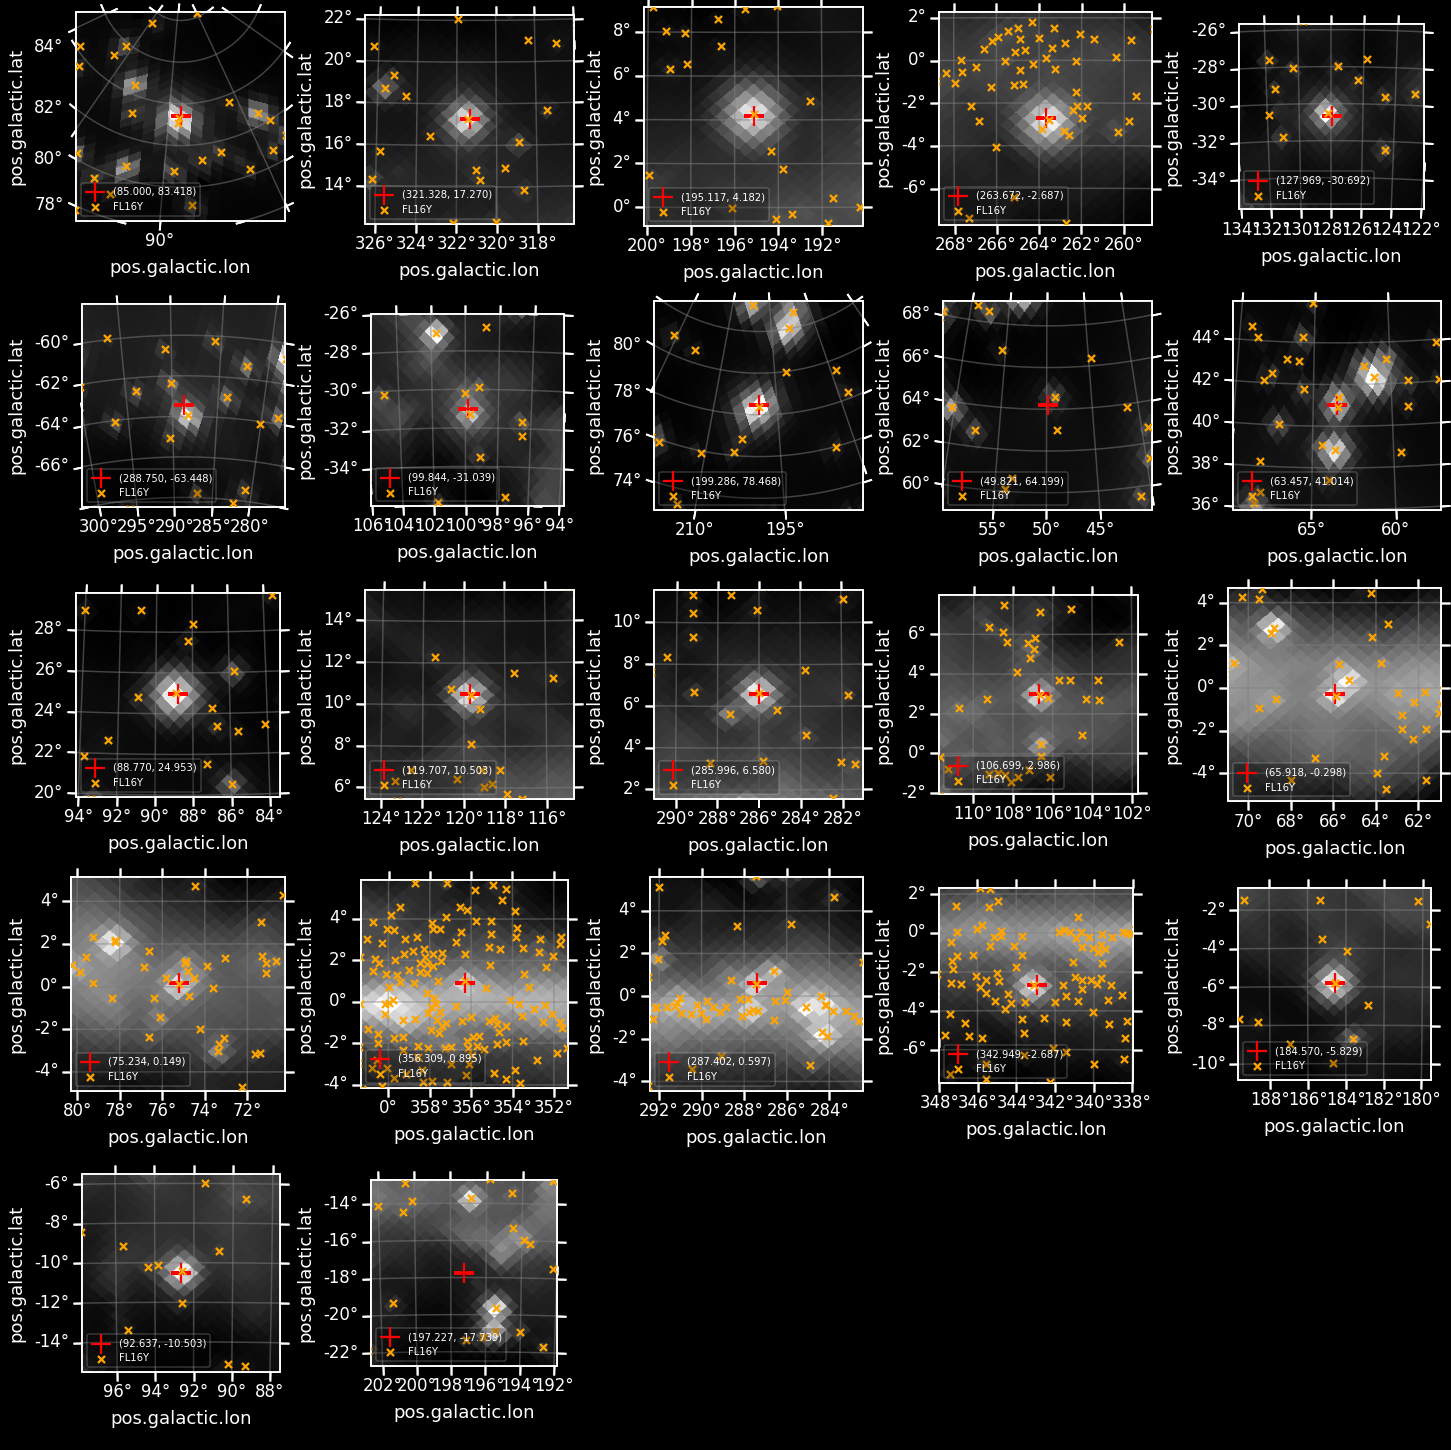

In [7]:
def residual_scatter(center, band,  fgl,*, component='model', fig=None, figsize=(8,8),**kwargs):
    
    (band.zea_plot(center=center, component=component, size=10, cmap='gist_gray',title='',
        fig=fig,figsize=figsize,  **kwargs)  
        .scatter(center,marker='+',color='red',s=400, 
                label=f'({center.l.deg:.3f}, {center.b.deg:.3f})')
        .scatter(fgl, marker='x',s=50, color='orange', label='FL16Y')
        .legend(loc='lower left',fontsize=10, framealpha=0.25)
    )
    if fig is not None: plt.gca().set(xlabel='',ylabel='', yticklabels=[], xticklabels=[])
    if fig is None: plt.show()


band = pixel_table(2,energy_index)
fig = plt.figure(figsize=(20,20))
subfigs = fig.subfigures(5,5)
for point, sfig in zip(self.clpoints, subfigs.flat):
    residual_scatter(point, band,  fgl, fig=sfig, colorbar=False, )
show(fig)

### Residual check plots for model<100 

,glon,glat,data,model,sigma,n,ids
5,-71.250,-63.448,93,52.2,5.6,3,"[10, 178, 34]"
6,99.844,-31.039,74,35.5,6.5,4,"[17, 153, 152, 18]"
8,49.821,64.199,9,1.9,5.2,2,"[48, 49]"
9,63.457,41.014,100,59.3,5.3,2,"[69, 70]"
21,-162.773,-17.739,12,2.6,5.7,2,"[137, 139]"


<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x765f71db93c0>
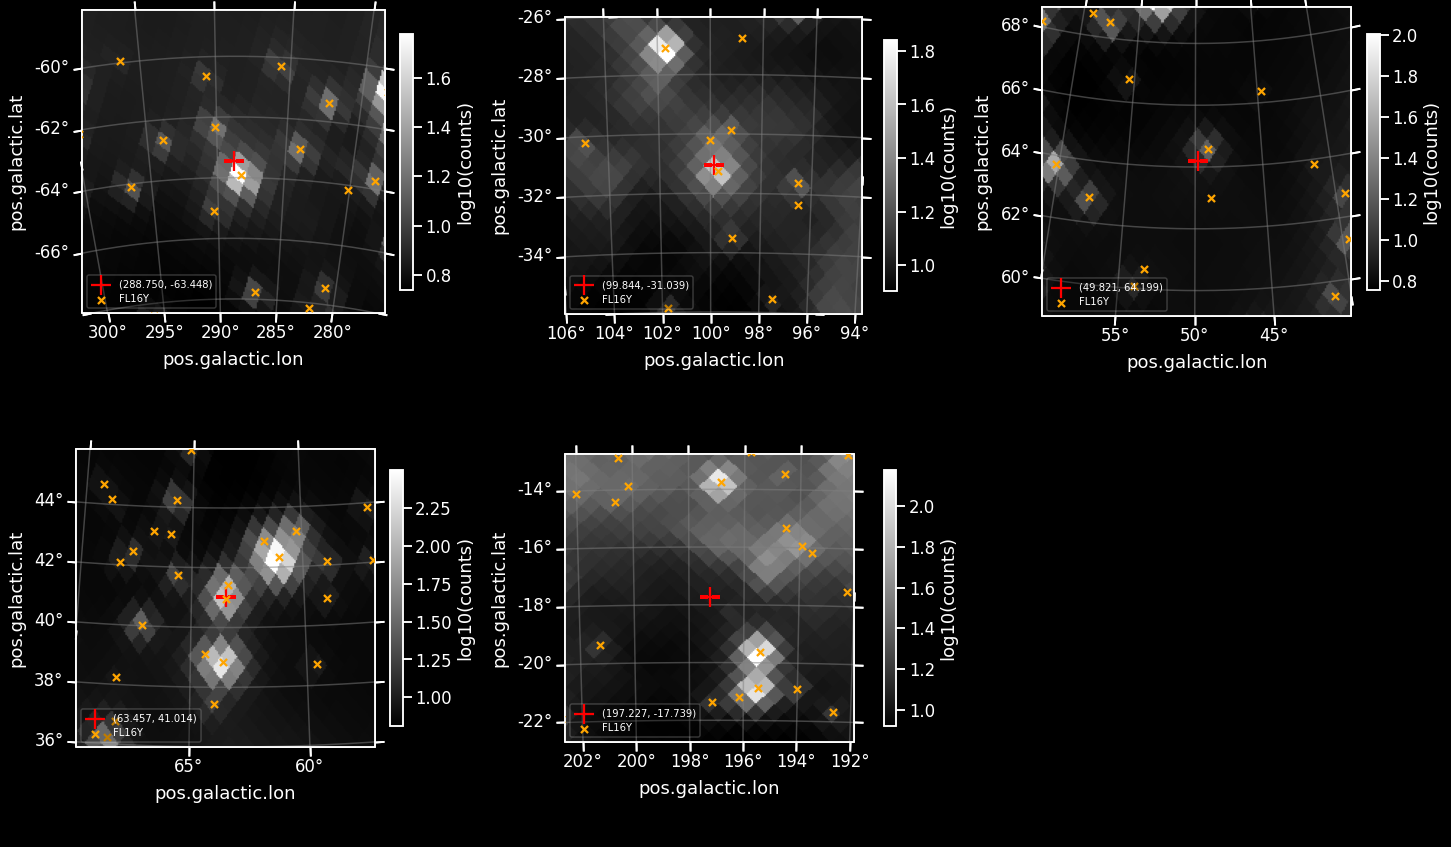

In [8]:
show(f"""### Residual check plots for model<100 """)
fig = plt.figure(figsize=(20,12))
subfigs = fig.subfigures(2,3)

df = self.cldf.query('model<100'); show(df)
for point, sfig in zip(SkyCoord(df.glon, df.glat, unit='deg',frame='galactic'), subfigs.flat):
    residual_scatter(point, band, fgl, component='model', fig=sfig, colorbar=True, )
show(fig)

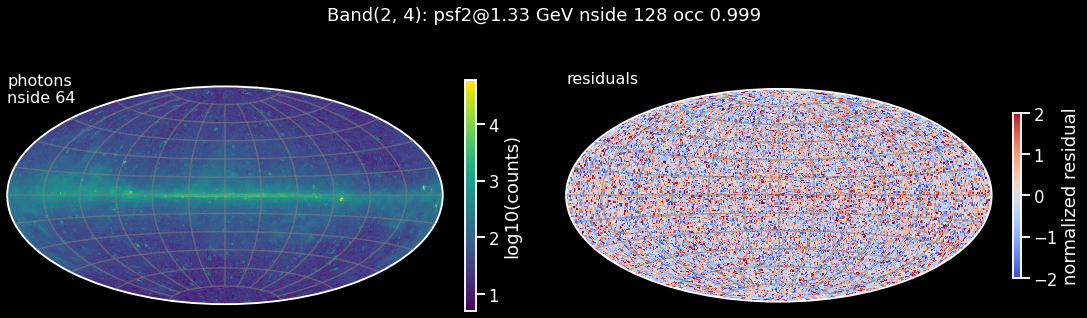

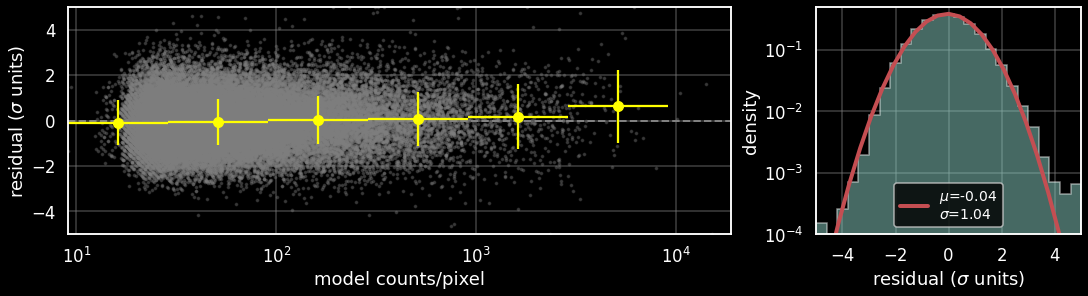

In [19]:
ResidualPlotter(pixel_table(2,4)).plots()

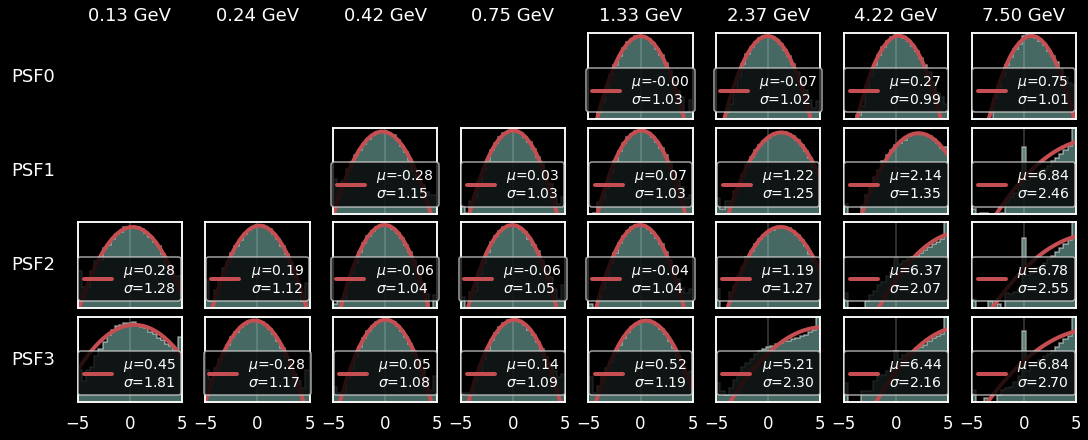

In [21]:
# assert False
multi_residual_plotter(pixel_table, nside=64)
# for i in range(0,6):
#     ResidualPlotter(pixel_table(2,i), 64).plots()
# for i in range(0,6):
#     ResidualPlotter(pixel_table(3,i)).plots()